# 2. Clustering

# 2.1

In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark


In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"
import time
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf
spark = SparkSession.builder.master("local[8]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark
sc = SparkContext.getOrCreate(spark.conf)


In [4]:
num_cores = sc.defaultParallelism
print("Number of CPU cores:", num_cores)


Number of CPU cores: 8


# الف

In [5]:
# Importing necessary libraries and modules
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.feature import VectorAssembler
from tqdm import tqdm
import numpy as np


C3.txt : BisectingKMeans: 100%|██████████| 24/24 [02:15<00:00,  5.65s/it]


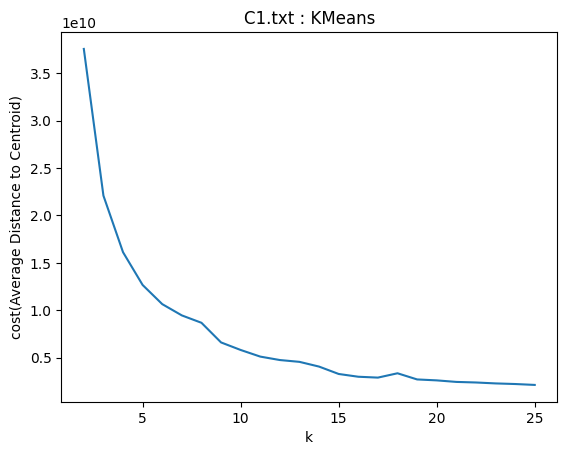

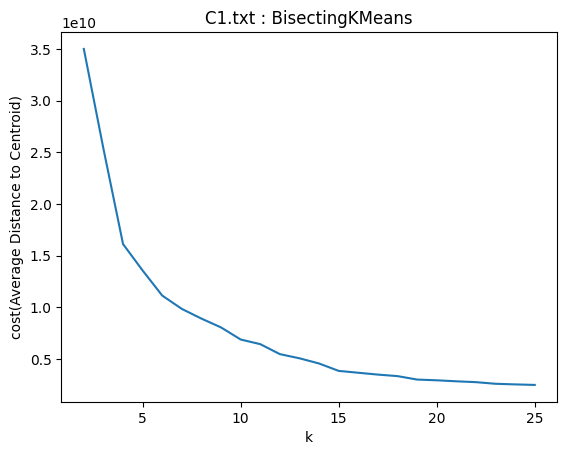

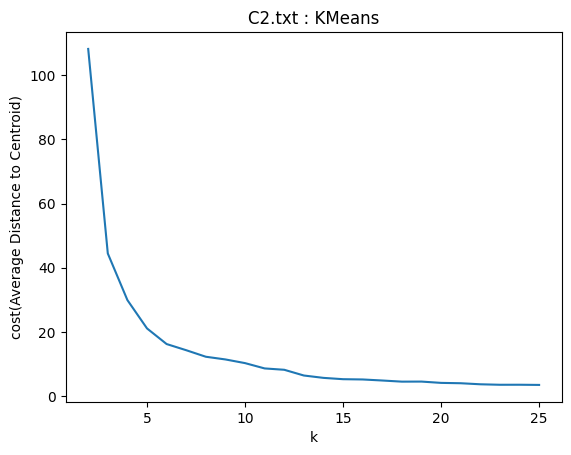

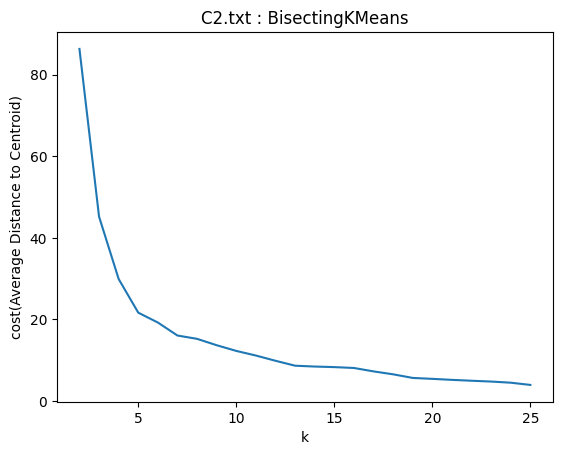

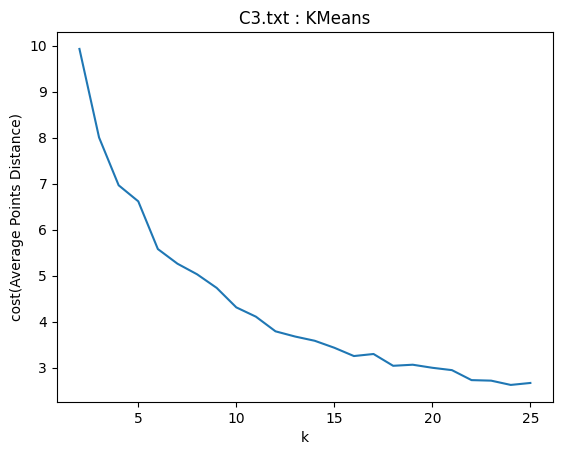

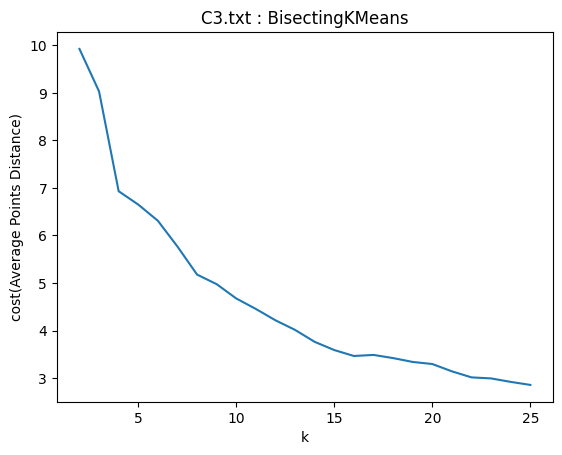

In [20]:
# Function to calculate the average distance of points to their respective cluster centroids
def avg_dis_to_centroid(predictions, centers):
    dis_sum = predictions.rdd.map(lambda Point: np.sum(np.array(Point.features - centers[Point.prediction])**2)).sum()
    return dis_sum / predictions.count()

# Function to calculate the sum of pairwise distances within a cluster
def Cluster_Distance(X):
    N = len(X[1])
    dis = 0
    for j in range(N):
        for t in range(j + 1, N):
            d = X[1][j] - X[1][t]
            d = np.sqrt(np.sum(d**2))
            dis = dis + d
    return np.array([dis, N * (N - 1) / 2])

# Function to calculate the average distance of points within a cluster
def avg_dis(predictions, _=None):
    rdd = predictions.rdd.map(lambda Point: (Point.prediction, np.array(Point.features)))
    rdd2 = rdd.groupByKey().mapValues(list).map(Cluster_Distance)
    Sum = rdd2.sum()
    return Sum[0] / Sum[1]

# List of file names, cost measures, and cost names
file_path1 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C1.txt"
file_path2 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C2.txt"
file_path3 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C3.txt"
Files = [file_path1, file_path2, file_path3]
File_names = ['C1.txt', 'C2.txt', 'C3.txt']
Cost_Measure = [avg_dis_to_centroid, avg_dis_to_centroid, avg_dis]
Cost_Name = ['Average Distance to Centroid', 'Average Distance to Centroid', 'Average Points Distance']
Max_K = 25

# Loop through each file
for i in range(0, len(File_names)):

    # Reading data from the file
    lines = sc.textFile(Files[i])
    cost_Measure = Cost_Measure[i]

    # Converting data to a DataFrame
    data = lines.map(lambda line: list(map(float, line.split())))
    df = data.toDF(['x1', 'x2'])
    vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
    df_kmeans = vecAssembler.transform(df).select('features')

    # Loop through different clustering algorithms (KMeans and BisectingKMeans)
    for Model_Type in [KMeans, BisectingKMeans]:
        with tqdm(total=Max_K-1, desc='{} : {}'.format(File_names[i], str(Model_Type).split('.')[-1][:-2])) as pbar:
            cost = []

            # Loop through different values of k (number of clusters)
            for k in range(2, Max_K + 1):
                kmeans = Model_Type().setK(k).setSeed(1)
                model = kmeans.fit(df_kmeans)
                predictions = model.transform(df_kmeans)
                cost.append(cost_Measure(predictions, model.clusterCenters()))
                pbar.update(1)

            # Plotting the cost for different values of k
            plt.figure()
            plt.plot(range(2, Max_K + 1), cost)
            plt.title("{} : {}".format(File_names[i], str(Model_Type).split('.')[-1][:-2]))
            plt.xlabel('k')
            plt.ylabel('cost({})'.format(Cost_Name[i]))

# Showing the plots
plt.show()


# ج

In [21]:
from pyspark.ml.functions import vector_to_array
import colorcet as cc

# Defining the optimal and minimum cost values for k for each dataset
optimal_k = [[15, 15], [14, 13], [18, 20]]
other_optimal_k = [[17, 19], [6, 7], [22, 22]]
min_cost_k = [[25, 25], [25, 25], [24, 25]]

# Defining file paths for three datasets
file_path1 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C1.txt"
file_path2 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C2.txt"
file_path3 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C3.txt"
Files = [file_path1, file_path2, file_path3]
File_names = ['C1.txt', 'C2.txt', 'C3.txt']
Model_Types = [KMeans, BisectingKMeans]

# Loop through each dataset
for i in range(0, len(File_names)):

    # Reading data from the file and convert it to a DataFrame
    lines = sc.textFile(Files[i])
    data = lines.map(lambda line: list(map(float, line.split())))
    df = data.toDF(['x1', 'x2'])
    vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
    df_kmeans = vecAssembler.transform(df).select('features')

    # Iterating through two clustering models: KMeans and BisectingKMeans
    with tqdm(total=2, desc=File_names[i]) as pbar:
        for j in range(len(Model_Types)):
            # Retrieving the optimal and minimum cost k values
            k_opt = optimal_k[i][j]
            k_opt_other = other_optimal_k[i][j]
            k_min_cost = min_cost_k[i][j]
            Model_Type = Model_Types[j]

            # Fiting the model with the optimal k value
            kmeans = Model_Type().setK(k_opt).setSeed(1)
            model = kmeans.fit(df_kmeans)
            predictions_opt = model.transform(df_kmeans)
            centers_opt = np.array(model.clusterCenters())

            # Fiting the model with the other optimal k value
            kmeans = Model_Type().setK(k_opt_other).setSeed(1)
            model = kmeans.fit(df_kmeans)
            predictions_opt_other = model.transform(df_kmeans)
            centers_opt_other = np.array(model.clusterCenters())

            # Fiting the model with the minimum cost k value
            kmeans = Model_Type().setK(k_min_cost).setSeed(1)
            model = kmeans.fit(df_kmeans)
            predictions_min_cost = model.transform(df_kmeans)
            centers_min_cost = np.array(model.clusterCenters())

            # Converting predictions to Pandas DataFrame for plotting
            a = predictions_opt.withColumn('features', vector_to_array('features')).toPandas()
            X_opt = np.array(list(a['features']))
            y_opt = list(a['prediction'])

            a = predictions_opt_other.withColumn('features', vector_to_array('features')).toPandas()
            X_opt_other = np.array(list(a['features']))
            y_opt_other = list(a['prediction'])

            a = predictions_min_cost.withColumn('features', vector_to_array('features')).toPandas()
            X_min_cost = np.array(list(a['features']))
            y_min_cost = list(a['prediction'])

            # Creating a subplot with two plots: Optimal k and Minimum cost k
            fig = plt.figure(figsize=(18, 6))
            plt.subplot(1, 3, 1)

            # y_opt contains cluster labels
            num_clusters = len(set(y_opt))

            # Using a perceptually uniform colormap from colorcet
            colors = cc.glasbey_light

            # Mapping cluster labels to colors
            color_dict = dict(zip(range(num_clusters), colors))
            cluster_colors = [color_dict[cluster] for cluster in y_opt]

            plt.scatter(X_opt[:, 0], X_opt[:, 1], c=cluster_colors, edgecolors='k', linewidth=0.5)
            plt.plot(centers_opt[:, 0], centers_opt[:, 1], 'r^')
            plt.title('Optimum (k = {})'.format(k_opt))

            plt.subplot(1, 3, 2)

            # y_opt_other contains cluster labels
            num_clusters = len(set(y_opt_other))

            # Using a perceptually uniform colormap from colorcet
            colors = cc.glasbey_light

            # Mapping cluster labels to colors
            color_dict = dict(zip(range(num_clusters), colors))
            cluster_colors = [color_dict[cluster] for cluster in y_opt_other]

            plt.scatter(X_opt_other[:, 0], X_opt_other[:, 1], c=cluster_colors, edgecolors='k', linewidth=0.5)
            plt.plot(centers_opt_other[:, 0], centers_opt_other[:, 1], 'r^')
            plt.title('Other Optimum (k = {})'.format(k_opt_other))

            plt.subplot(1, 3, 3)

            # y_min_cost contains cluster labels
            num_clusters = len(set(y_min_cost))

            # Using a perceptually uniform colormap from colorcet
            colors = cc.glasbey_light

            # Mapping cluster labels to colors
            color_dict = dict(zip(range(num_clusters), colors))
            cluster_colors = [color_dict[cluster] for cluster in y_min_cost]

            plt.scatter(X_min_cost[:, 0], X_min_cost[:, 1], c=cluster_colors, edgecolors='k', linewidth=0.5)
            plt.plot(centers_min_cost[:, 0], centers_min_cost[:, 1], 'r^')
            plt.title('Min Cost (k = {})'.format(k_min_cost))

            # Setting the overall title for the subplots
            fig.suptitle("{} : {}".format(File_names[i], str(Model_Type).split('.')[-1][:-2]))
            pbar.update(1)

# Displaying the plots
plt.show()


Output hidden; open in https://colab.research.google.com to view.

# د

In [6]:
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.feature import VectorAssembler

# Defining file paths for three datasets and optimal k values
file_path1 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C1.txt"
file_path2 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C2.txt"
file_path3 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/C3.txt"
Files_name = [file_path1, file_path2, file_path3]
optimal_k = [[17, 19], [14, 13], [22, 22]]


In [7]:
# running with 1 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Elapsed time: 39.51 seconds


In [8]:
# running with 1 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Elapsed time: 18.42 seconds


In [9]:
# running with 1 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 8.53 seconds


In [10]:
# running with 1 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 9.23 seconds


In [11]:
# running with 1 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 5.40 seconds


In [12]:
# running with 1 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 7.31 seconds


In [7]:
# running with 2 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 22.69 seconds


In [8]:
# running with 2 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 15.13 seconds


In [9]:
# running with 2 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 3.72 seconds


In [10]:
# running with 2 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 9.18 seconds


In [11]:
# running with 2 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 3.14 seconds


In [12]:
# running with 2 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 7.85 seconds


In [7]:
# running with 3 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 37.60 seconds


In [8]:
# running with 3 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 19.81 seconds


In [9]:
# running with 3 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 7.70 seconds


In [10]:
# running with 3 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 12.62 seconds


In [11]:
# running with 3 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 6.12 seconds


In [12]:
# running with 3 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 10.39 seconds


In [7]:
# running with 4 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 38.65 seconds


In [8]:
# running with 4 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 19.52 seconds


In [9]:
# running with 4 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 7.46 seconds


In [10]:
# running with 4 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 10.06 seconds


In [11]:
# running with 4 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 5.43 seconds


In [12]:
# running with 4 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 9.34 seconds


In [7]:
# running with 5 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 48.70 seconds


In [8]:
# running with 5 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 20.51 seconds


In [9]:
# running with 5 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 4.30 seconds


In [10]:
# running with 5 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 13.69 seconds


In [11]:
# running with 5 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 3.91 seconds


In [12]:
# running with 5 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 11.78 seconds


In [7]:
# running with 6 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 35.65 seconds


In [8]:
# running with 6 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 20.45 seconds


In [9]:
# running with 6 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 6.87 seconds


In [10]:
# running with 6 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 12.95 seconds


In [11]:
# running with 6 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 6.56 seconds


In [12]:
# running with 6 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 11.28 seconds


In [7]:
# running with 7 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 33.23 seconds


In [8]:
# running with 7 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 20.78 seconds


In [9]:
# running with 7 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 6.58 seconds


In [10]:
# running with 7 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 7.79 seconds


In [11]:
# running with 7 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 3.81 seconds


In [12]:
# running with 7 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 10.16 seconds


In [7]:
# running with 8 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 38.40 seconds


In [8]:
# running with 8 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 1  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 19.96 seconds


In [9]:
# running with 8 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 4.09 seconds


In [10]:
# running with 8 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 2  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 13.35 seconds


In [11]:
# running with 8 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = KMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 3.91 seconds


In [12]:
# running with 8 cpu unit
# Specifying parameters: File_index and Model_Type
File_index = 3  # [1 , 2 , 3]
Model_Type = BisectingKMeans  # [KMeans , BisectingKMeans]

# Selecting the file path and k value based on File_index and Model_Type
File_Name = Files_name[File_index - 1]
if Model_Type == KMeans:
    k = optimal_k[File_index - 1][0]
else:
    k = optimal_k[File_index - 1][1]

# Recording the start time
start_time = time.time()

# Reading data from the selected file and convert it to a DataFrame
lines = sc.textFile(File_Name)
data = lines.map(lambda line: list(map(float, line.split())))
df = data.toDF(['x1', 'x2'])
vecAssembler = VectorAssembler(inputCols=['x1', 'x2'], outputCol="features")
df_kmeans = vecAssembler.transform(df).select('features')

# Configure and fit the clustering model
kmeans = Model_Type().setK(k).setSeed(1)
model = kmeans.fit(df_kmeans)
predictions = model.transform(df_kmeans)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds
elapsed_time_seconds = end_time - start_time

# Print the elapsed time
print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")

Elapsed time: 10.02 seconds


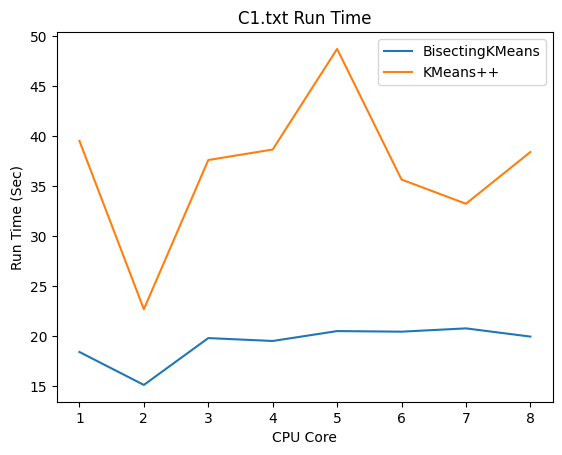

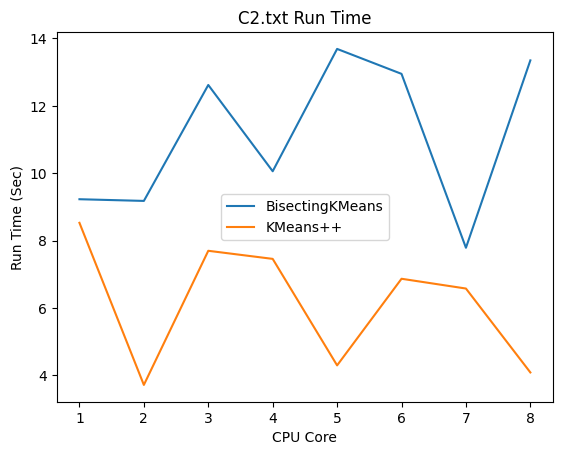

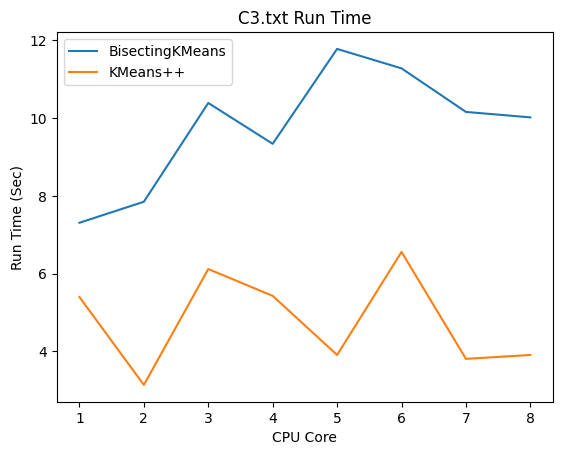

In [13]:
# c1
# KMeans 39.51 22.69 37.60 38.65 48.70 35.65 33.23 38.40
# BisectingKMeans 18.42 15.13 19.81 19.52 20.51 20.45 20.78 19.96
# c2
# KMeans 8.53 3.72 7.70 7.46 4.30 6.87 6.58 4.09
# BisectingKMeans 9.23 9.18 12.62 10.06 13.69 12.95 7.79 13.35
# c3
# KMeans 5.40 3.14 6.12 5.43 3.91 6.56 3.81 3.91
# BisectingKMeans 7.31 7.85 10.39 9.34 11.78 11.28 10.16 10.02

import matplotlib.pyplot as plt

# Defining the number of CPU cores
Core = [1, 2, 3, 4, 5, 6, 7, 8]

# Defining run times for different configurations of datasets and clustering algorithms

# C1.txt dataset run times
C1_BisectingKMeans = [18.42, 15.13, 19.81, 19.52, 20.51, 20.45, 20.78, 19.96]
C1_KMeans = [39.51, 22.69, 37.60, 38.65, 48.70, 35.65, 33.23, 38.40]

# C2.txt dataset run times
C2_BisectingKMeans = [9.23, 9.18, 12.62, 10.06, 13.69, 12.95, 7.79, 13.35]
C2_KMeans = [8.53, 3.72, 7.70, 7.46, 4.30, 6.87, 6.58, 4.09]

# C3.txt dataset run times
C3_BisectingKMeans = [7.31, 7.85, 10.39, 9.34, 11.78, 11.28, 10.16, 10.02]
C3_KMeans = [5.40, 3.14, 6.12, 5.43, 3.91, 6.56, 3.81, 3.91]

# Plotting the run times for C1.txt dataset
plt.figure()
plt.plot(Core, C1_BisectingKMeans, label='BisectingKMeans')
plt.plot(Core, C1_KMeans, label='KMeans++')
plt.title("C1.txt Run Time")
plt.xlabel('CPU Core')
plt.ylabel('Run Time (Sec)')
plt.legend()

# Plotting the run times for C2.txt dataset
plt.figure()
plt.plot(Core, C2_BisectingKMeans, label='BisectingKMeans')
plt.plot(Core, C2_KMeans, label='KMeans++')
plt.title("C2.txt Run Time")
plt.xlabel('CPU Core')
plt.ylabel('Run Time (Sec)')
plt.legend()

# Plotting the run times for C3.txt dataset
plt.figure()
plt.plot(Core, C3_BisectingKMeans, label='BisectingKMeans')
plt.plot(Core, C3_KMeans, label='KMeans++')
plt.title("C3.txt Run Time")
plt.xlabel('CPU Core')
plt.ylabel('Run Time (Sec)')
plt.legend()

# Displaying the plots
plt.show()
